# Panorama Scene Data Audit Notebook

Notebook này dùng để **audit chất lượng dataset trước khi kết luận scene có nên đem đi stitch hay không**.

Khác với notebook OpenCV stitcher:
- `01_data_audit.ipynb` tập trung vào **quality screening** và **giải thích nguyên nhân rủi ro**
- `06_opencv_scene_stitcher.ipynb` tập trung vào **kết quả stitch thật**

Bản nâng cấp này được tách thành nhiều module nhỏ. Mỗi module có:
- một markdown cell giải thích nó làm gì
- một code cell riêng để bạn đọc, sửa và chạy độc lập


## Module 1. Imports and Notebook Setup

Module này nạp toàn bộ thư viện cần thiết cho audit:
- `cv2`, `numpy`, `pandas` cho xử lý ảnh và bảng kết quả
- `matplotlib` để vẽ histogram và ảnh debug
- `project_utils.panorama_dataset` để lấy đúng thứ tự ảnh trong từng scene theo `meta.json`

Đây chỉ là phần nền tảng để các module phía sau dùng chung.


In [10]:
from __future__ import annotations

import json
import math
import sys
from dataclasses import dataclass, asdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'project_utils').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project_utils.panorama_dataset import list_scene_dirs, ordered_scene_files

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('OpenCV =', cv2.__version__)


PROJECT_ROOT = F:\CV\School\Project
OpenCV = 4.13.0


## Module 2. Paths and Output Layout

Module này định nghĩa:
- nơi đọc dữ liệu gốc (`data/raw`)
- nơi lưu output audit (`outputs/audit`)
- các thư mục con để lưu ảnh debug nếu cần

Mục tiêu là giúp notebook chạy lặp lại nhiều lần mà không cần sửa path ở nhiều chỗ.


In [11]:
DATA_ROOT = PROJECT_ROOT / 'data' / 'raw'
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'audit'
OUTPUT_KEYPOINT_DIR = OUTPUT_ROOT / 'keypoints'
OUTPUT_MATCH_DIR = OUTPUT_ROOT / 'matches'
OUTPUT_INLIER_DIR = OUTPUT_ROOT / 'inliers'

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_KEYPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_MATCH_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_INLIER_DIR.mkdir(parents=True, exist_ok=True)

OPENCV_LOG_ROOT = PROJECT_ROOT / 'outputs' / 'openCV' / 'logs'

print('DATA_ROOT =', DATA_ROOT)
print('OUTPUT_ROOT =', OUTPUT_ROOT)
print('OPENCV_LOG_ROOT =', OPENCV_LOG_ROOT)


DATA_ROOT = F:\CV\School\Project\data\raw
OUTPUT_ROOT = F:\CV\School\Project\outputs\audit
OPENCV_LOG_ROOT = F:\CV\School\Project\outputs\openCV\logs


## Module 3. Audit Configuration and Thresholds

Đây là module quan trọng nhất về mặt policy.

Nó trả lời:
- feature extractor nào sẽ được dùng
- scene được resize tới mức nào khi audit
- ngưỡng nào được xem là đáng lo ở mức ảnh
- ngưỡng nào được xem là đáng lo ở mức pair

Bản mới có **2 tầng ngưỡng**:
- `MIN_*`: dưới mức này là fail cứng
- `WARN_*`: trên fail nhưng vẫn đủ để cảnh báo `weak / borderline`

Cách chia này giúp scene classification bớt quá lạc quan.


In [12]:
FEATURE_METHOD = 'orb'  # 'orb' or 'sift'
ORB_NFEATURES = 4000
RATIO_TEST = 0.75
RANSAC_REPROJ_THRESHOLD = 4.0
MIN_GOOD_MATCHES_FOR_H = 8
MAX_LONG_EDGE = 2200
SAVE_VISUALS = False
RUN_SKIP_PAIR_CHECK = True
MAX_SKIP_GAP = 2

THRESH = {
    'min_blur_score': 80.0,
    'warn_blur_score': 120.0,
    'min_keypoints': 150,
    'warn_keypoints': 450,
    'min_good_matches': 40,
    'warn_good_matches': 90,
    'min_inliers': 20,
    'warn_inliers': 45,
    'min_inlier_ratio': 0.35,
    'warn_inlier_ratio': 0.50,
    'max_reproj_error': 4.0,
    'warn_reproj_error': 2.5,
    'min_overlap_ratio': 0.10,
    'warn_overlap_ratio': 0.18,
    'max_brightness_gap': 50.0,
    'warn_brightness_gap': 25.0,
    'min_entropy': 5.5,
    'warn_entropy': 6.2,
}

SCENE_RULES = {
    'good_min_pair_score': 0.82,
    'borderline_min_pair_score': 0.60,
}

print('FEATURE_METHOD =', FEATURE_METHOD)
print('MAX_LONG_EDGE =', MAX_LONG_EDGE)
print('RUN_SKIP_PAIR_CHECK =', RUN_SKIP_PAIR_CHECK)
print('SAVE_VISUALS =', SAVE_VISUALS)


FEATURE_METHOD = orb
MAX_LONG_EDGE = 2200
RUN_SKIP_PAIR_CHECK = True
SAVE_VISUALS = False


## Module 4. Dataset, Metadata, and Log Helpers

Module này gom các helper về dữ liệu:
- lấy đúng chuỗi ảnh theo `ordered_files`
- tách `reference_files` ra khỏi chain audit
- đọc `meta.json`
- đọc log OpenCV đã có sẵn nếu tồn tại

Đây là cầu nối giữa notebook audit và phần còn lại của project.


In [13]:
def list_image_files(scene_dir: Path):
    ordered_files, _, _, _ = ordered_scene_files(scene_dir)
    return ordered_files


def list_reference_files(scene_dir: Path):
    _, reference_files, _, _ = ordered_scene_files(scene_dir)
    return reference_files


def load_scene_meta(scene_dir: Path) -> dict:
    _, _, meta, _ = ordered_scene_files(scene_dir)
    return meta or {}


def load_opencv_summary(scene_id: str) -> dict:
    path = OPENCV_LOG_ROOT / f'{scene_id}_opencv_panorama_summary.json'
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding='utf-8'))


def scene_context_row(scene_dir: Path) -> dict:
    ordered_files, reference_files, meta, used_meta_order = ordered_scene_files(scene_dir)
    audit_summary = (meta or {}).get('audit_summary', {}) or {}
    stability = audit_summary.get('stability_check', {}) or {}
    opencv = load_opencv_summary(scene_dir.name)
    return {
        'scene_id': scene_dir.name,
        'num_images': len(ordered_files),
        'num_reference_files': len(reference_files),
        'reference_files': ', '.join(path.name for path in reference_files),
        'used_meta_order': bool(used_meta_order),
        'meta_category': meta.get('category'),
        'meta_capture_group': meta.get('capture_group'),
        'meta_difficulty': meta.get('difficulty'),
        'meta_recommended_use': meta.get('recommended_use'),
        'meta_stitcher_status': audit_summary.get('stitcher_status'),
        'meta_ok_rate': stability.get('ok_rate'),
        'meta_stability_label': stability.get('stability_label'),
        'opencv_status_name': opencv.get('status_name'),
        'opencv_panorama_shape': opencv.get('panorama_shape'),
    }


## Module 5. Visualization Helpers

Audit không chỉ là bảng số. Khi một pair yếu, chúng ta thường cần xem:
- keypoint có nằm đúng vùng không
- match có tập trung vào overlap thật không
- inlier có còn đủ sạch sau RANSAC không

Module này tạo các ảnh debug đó. Mặc định notebook không lưu vì khá nặng,
nhưng khi `SAVE_VISUALS = True` thì bạn sẽ có ảnh minh hoạ để kiểm từng scene.


In [14]:
def bgr_to_rgb(image_bgr: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def show_bgr(image_bgr: np.ndarray, title: str | None = None, figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(bgr_to_rgb(image_bgr))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


def save_bgr(path: Path, image_bgr: np.ndarray):
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image_bgr)


def draw_keypoints_image(image_bgr, keypoints):
    return cv2.drawKeypoints(
        image_bgr,
        keypoints,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
        color=(0, 255, 0),
    )


def draw_matches_image(img1, kp1, img2, kp2, matches, max_draw=80):
    draw_matches = sorted(matches, key=lambda match: match.distance)[:max_draw]
    return cv2.drawMatches(
        img1,
        kp1,
        img2,
        kp2,
        draw_matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )


def draw_inlier_matches_image(img1, kp1, img2, kp2, matches, mask, max_draw=80):
    if mask is None:
        return draw_matches_image(img1, kp1, img2, kp2, matches, max_draw=max_draw)
    keep = mask.ravel().astype(bool)
    inlier_matches = [match for match, is_inlier in zip(matches, keep) if is_inlier]
    return draw_matches_image(img1, kp1, img2, kp2, inlier_matches, max_draw=max_draw)


## Module 6. Image Loading, Resize, and Image-Level Metrics

Module này đánh giá từng ảnh độc lập, trước cả khi nhìn sang ảnh bên cạnh.

Các metric chính:
- `brightness_mean`: ảnh quá tối hoặc quá sáng sẽ khó match
- `contrast_std`: độ tương phản tổng quát
- `blur_score`: dùng phương sai Laplacian, thấp thường gợi ý ảnh mờ
- `entropy`: ảnh quá phẳng thì thường ít texture
- `keypoints`: ảnh có đủ chi tiết đặc trưng hay không

Ở mức này, notebook chưa biết panorama có stitch được không. Nó chỉ trả lời:
từng ảnh có đủ chất lượng để tham gia pipeline không.


In [15]:
def resize_long_edge(image_bgr: np.ndarray, max_long_edge: int) -> np.ndarray:
    height, width = image_bgr.shape[:2]
    long_edge = max(height, width)
    if long_edge <= max_long_edge:
        return image_bgr
    scale = max_long_edge / long_edge
    return cv2.resize(
        image_bgr,
        (int(round(width * scale)), int(round(height * scale))),
        interpolation=cv2.INTER_AREA,
    )


def load_bgr(path: Path, max_long_edge: int = MAX_LONG_EDGE):
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f'Cannot read image: {path}')
    return resize_long_edge(image, max_long_edge)


def to_gray(image_bgr):
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)


def brightness_mean(gray):
    return float(gray.mean())


def contrast_std(gray):
    return float(gray.std())


def blur_score_laplacian(gray):
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


def entropy_bits(gray):
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel().astype(np.float64)
    prob = hist / max(hist.sum(), 1.0)
    prob = prob[prob > 0]
    return float(-(prob * np.log2(prob)).sum())


def normalize_score(value, *, good_if_high, good_threshold, bad_threshold):
    if value is None or not np.isfinite(value):
        return 0.0
    if good_if_high:
        if value >= good_threshold:
            return 1.0
        if value <= bad_threshold:
            return 0.0
        return float((value - bad_threshold) / max(good_threshold - bad_threshold, 1e-9))
    if value <= good_threshold:
        return 1.0
    if value >= bad_threshold:
        return 0.0
    return float((bad_threshold - value) / max(bad_threshold - good_threshold, 1e-9))


def score_image_metrics(blur, n_keypoints, entropy):
    s_blur = normalize_score(
        blur,
        good_if_high=True,
        good_threshold=max(THRESH['warn_blur_score'] * 2, THRESH['warn_blur_score'] + 1),
        bad_threshold=max(10.0, THRESH['min_blur_score'] * 0.25),
    )
    s_keypoints = normalize_score(
        n_keypoints,
        good_if_high=True,
        good_threshold=max(THRESH['warn_keypoints'] * 2, THRESH['warn_keypoints'] + 1),
        bad_threshold=max(20, int(THRESH['min_keypoints'] * 0.2)),
    )
    s_entropy = normalize_score(
        entropy,
        good_if_high=True,
        good_threshold=max(THRESH['warn_entropy'], THRESH['min_entropy'] + 0.6),
        bad_threshold=max(2.0, THRESH['min_entropy'] - 1.5),
    )
    return float(0.40 * s_blur + 0.35 * s_keypoints + 0.25 * s_entropy)


## Module 7. Feature Extraction and Pair Geometry

Đây là phần xương sống của audit.

Cho mỗi cặp ảnh, notebook sẽ:
1. detect keypoints + descriptors
2. match descriptors bằng ratio test
3. estimate homography bằng RANSAC
4. đo số inlier, reprojection error và overlap ratio

Nếu bước này yếu, scene thường có rủi ro cao khi stitch thật.


In [16]:
def make_feature_detector(method='orb'):
    method = method.lower()
    if method == 'orb':
        return cv2.ORB_create(nfeatures=ORB_NFEATURES)
    if method == 'sift':
        if hasattr(cv2, 'SIFT_create'):
            return cv2.SIFT_create(nfeatures=4000)
        raise RuntimeError('SIFT is not available in this OpenCV build.')
    raise ValueError("method must be 'orb' or 'sift'")


def detect_and_describe(gray, method='orb'):
    detector = make_feature_detector(method)
    keypoints, descriptors = detector.detectAndCompute(gray, None)
    if keypoints is None:
        keypoints = []
    return keypoints, descriptors


def make_matcher(method='orb'):
    method = method.lower()
    if method == 'orb':
        return cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    if method == 'sift':
        return cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    raise ValueError("method must be 'orb' or 'sift'")


def knn_ratio_match(des1, des2, method='orb', ratio=0.75):
    if des1 is None or des2 is None or len(des1) == 0 or len(des2) == 0:
        return [], []
    matcher = make_matcher(method)
    knn = matcher.knnMatch(des1, des2, k=2)
    good = []
    for pair in knn:
        if len(pair) < 2:
            continue
        first, second = pair
        if first.distance < ratio * second.distance:
            good.append(first)
    return knn, good


def keypoints_to_xy(keypoints, matches, *, query=True):
    pts = []
    for match in matches:
        index = match.queryIdx if query else match.trainIdx
        pts.append(keypoints[index].pt)
    return np.float32(pts).reshape(-1, 1, 2)


def estimate_homography(kp1, kp2, good_matches, reproj_thresh=RANSAC_REPROJ_THRESHOLD):
    if len(good_matches) < MIN_GOOD_MATCHES_FOR_H:
        return None, None
    src_pts = keypoints_to_xy(kp1, good_matches, query=True)
    dst_pts = keypoints_to_xy(kp2, good_matches, query=False)
    homography, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, reproj_thresh)
    return homography, mask


def reprojection_error(kp1, kp2, matches, homography, inlier_mask):
    if homography is None or inlier_mask is None:
        return float('inf')
    keep = inlier_mask.ravel().astype(bool)
    if keep.sum() == 0:
        return float('inf')
    inlier_matches = [match for match, is_inlier in zip(matches, keep) if is_inlier]
    src = keypoints_to_xy(kp1, inlier_matches, query=True)
    dst = keypoints_to_xy(kp2, inlier_matches, query=False)
    projected = cv2.perspectiveTransform(src, homography)
    error = np.linalg.norm(projected - dst, axis=2).reshape(-1)
    return float(np.median(error)) if len(error) else float('inf')


def estimate_overlap_ratio(shape1, shape2, homography):
    height1, width1 = shape1[:2]
    height2, width2 = shape2[:2]
    mask1 = np.ones((height1, width1), dtype=np.uint8) * 255
    warped = cv2.warpPerspective(mask1, homography, (width2, height2))
    overlap_pixels = int(np.count_nonzero(warped > 0))
    return float(overlap_pixels / max(height2 * width2, 1))


def analyze_pair(image_a_bgr, image_b_bgr, image_a_name, image_b_name, *, feature_method=FEATURE_METHOD, ratio_test=RATIO_TEST):
    gray_a = to_gray(image_a_bgr)
    gray_b = to_gray(image_b_bgr)
    kp_a, des_a = detect_and_describe(gray_a, method=feature_method)
    kp_b, des_b = detect_and_describe(gray_b, method=feature_method)
    knn, good = knn_ratio_match(des_a, des_b, method=feature_method, ratio=ratio_test)
    homography, mask = estimate_homography(kp_a, kp_b, good, reproj_thresh=RANSAC_REPROJ_THRESHOLD)
    homography_ok = homography is not None and mask is not None

    if homography_ok:
        inliers = int(mask.sum())
        inlier_ratio = float(inliers / max(len(good), 1))
        reproj = reprojection_error(kp_a, kp_b, good, homography, mask)
        overlap = estimate_overlap_ratio(gray_a.shape, gray_b.shape, homography)
    else:
        inliers = 0
        inlier_ratio = 0.0
        reproj = float('inf')
        overlap = 0.0

    brightness_gap = abs(brightness_mean(gray_a) - brightness_mean(gray_b))

    return {
        'image_a': image_a_name,
        'image_b': image_b_name,
        'raw_knn_pairs': int(len(knn)),
        'good_matches': int(len(good)),
        'homography_ok': bool(homography_ok),
        'inliers': int(inliers),
        'inlier_ratio': float(inlier_ratio),
        'reprojection_error': float(reproj),
        'overlap_ratio': float(overlap),
        'brightness_gap': float(brightness_gap),
        '_kp_a': kp_a,
        '_kp_b': kp_b,
        '_good_matches': good,
        '_mask': mask,
    }


## Module 8. Pair Scoring, Skip-Pair Check, and Scene Classification

Đây là nơi notebook chuyển từ đo số sang ra quyết định.

Tầng pair:
- `strong`: sạch, an toàn
- `ok`: dùng được nhưng chưa đẹp
- `weak`: có rủi ro
- `fail`: không nên tin

Tầng scene:
- nếu có pair `fail` thì scene bị kéo xuống mạnh
- nếu không fail nhưng có pair `weak` hoặc `skip-pair` yếu thì scene là `borderline`
- chỉ khi chuỗi sạch tương đối đồng đều mới lên `likely_good`

`skip-pair check` là điểm mới so với notebook cũ:
- ngoài cặp kề nhau, notebook sẽ thử thêm cặp `i -> i+2`
- mục tiêu là phát hiện các scene mà pairwise nhìn đẹp nhưng chuỗi toàn cục không ổn


In [17]:
def score_pair_metrics(good_matches, inliers, inlier_ratio, reproj_err, overlap_ratio, brightness_gap):
    s_good = normalize_score(
        good_matches,
        good_if_high=True,
        good_threshold=max(THRESH['warn_good_matches'] * 2, THRESH['warn_good_matches'] + 1),
        bad_threshold=max(5, THRESH['min_good_matches'] * 0.25),
    )
    s_inliers = normalize_score(
        inliers,
        good_if_high=True,
        good_threshold=max(THRESH['warn_inliers'] * 2, THRESH['warn_inliers'] + 1),
        bad_threshold=max(4, THRESH['min_inliers'] * 0.25),
    )
    s_ratio = normalize_score(
        inlier_ratio,
        good_if_high=True,
        good_threshold=min(0.80, max(0.60, THRESH['warn_inlier_ratio'] + 0.1)),
        bad_threshold=max(0.05, THRESH['min_inlier_ratio'] * 0.3),
    )
    s_reproj = normalize_score(
        reproj_err,
        good_if_high=False,
        good_threshold=THRESH['warn_reproj_error'],
        bad_threshold=max(THRESH['max_reproj_error'] * 3, THRESH['max_reproj_error'] + 5),
    )
    s_overlap = normalize_score(
        overlap_ratio,
        good_if_high=True,
        good_threshold=max(0.30, THRESH['warn_overlap_ratio'] + 0.10),
        bad_threshold=max(0.01, THRESH['min_overlap_ratio'] * 0.2),
    )
    s_brightness = normalize_score(
        brightness_gap,
        good_if_high=False,
        good_threshold=THRESH['warn_brightness_gap'],
        bad_threshold=max(THRESH['max_brightness_gap'] * 2, THRESH['max_brightness_gap'] + 40),
    )
    return float(0.15 * s_good + 0.18 * s_inliers + 0.25 * s_ratio + 0.18 * s_reproj + 0.14 * s_overlap + 0.10 * s_brightness)


def pair_issue_flags(row: dict) -> list[str]:
    flags = []
    if not row['homography_ok']:
        flags.append('homography_failed')
    if row['good_matches'] < THRESH['min_good_matches']:
        flags.append('too_few_good_matches')
    if row['inliers'] < THRESH['min_inliers']:
        flags.append('too_few_inliers')
    if row['inlier_ratio'] < THRESH['min_inlier_ratio']:
        flags.append('low_inlier_ratio')
    if row['overlap_ratio'] < THRESH['min_overlap_ratio']:
        flags.append('insufficient_overlap')
    if row['reprojection_error'] > THRESH['max_reproj_error']:
        flags.append('high_reprojection_error')
    if row['brightness_gap'] > THRESH['max_brightness_gap']:
        flags.append('large_brightness_gap')
    return flags


def classify_pair(row: dict) -> str:
    hard_fail = (
        (not row['homography_ok'])
        or row['good_matches'] < THRESH['min_good_matches']
        or row['inliers'] < THRESH['min_inliers']
        or row['inlier_ratio'] < THRESH['min_inlier_ratio']
        or row['overlap_ratio'] < THRESH['min_overlap_ratio']
        or row['reprojection_error'] > THRESH['max_reproj_error']
    )
    if hard_fail:
        return 'fail'

    weak_warn = (
        row['good_matches'] < THRESH['warn_good_matches']
        or row['inliers'] < THRESH['warn_inliers']
        or row['inlier_ratio'] < THRESH['warn_inlier_ratio']
        or row['overlap_ratio'] < THRESH['warn_overlap_ratio']
        or row['reprojection_error'] > THRESH['warn_reproj_error']
        or row['brightness_gap'] > THRESH['warn_brightness_gap']
    )
    if weak_warn:
        return 'weak'

    if row['pair_score'] >= SCENE_RULES['good_min_pair_score']:
        return 'strong'
    return 'ok'


def label_counts(rows: list[dict], key: str = 'pair_label') -> dict:
    counts = {'strong': 0, 'ok': 0, 'weak': 0, 'fail': 0}
    for row in rows:
        label = row.get(key)
        if label in counts:
            counts[label] += 1
    return counts


def skip_pair_problem(row: dict) -> bool:
    if row['good_matches'] < THRESH['min_good_matches']:
        return False
    if row['pair_label'] == 'fail':
        return True
    if row['pair_label'] == 'weak' and row['pair_score'] < SCENE_RULES['borderline_min_pair_score']:
        return True
    return False


def summarize_scene_reasons(adjacent_rows: list[dict], skip_rows: list[dict]) -> list[str]:
    reasons = []
    if any(row['pair_label'] == 'fail' for row in adjacent_rows):
        reasons.append('adjacent_pair_failed')
    if any(row['pair_label'] == 'weak' for row in adjacent_rows):
        reasons.append('adjacent_pair_weak')
    if skip_rows and any(skip_pair_problem(row) for row in skip_rows):
        reasons.append('skip_pair_inconsistency')
    if any(row['brightness_gap'] > THRESH['warn_brightness_gap'] for row in adjacent_rows):
        reasons.append('brightness_shift')
    if any(row['overlap_ratio'] < THRESH['warn_overlap_ratio'] for row in adjacent_rows):
        reasons.append('low_overlap')
    return reasons


def classify_scene(adjacent_rows: list[dict], skip_rows: list[dict]):
    if not adjacent_rows:
        return 'likely_fail', 0.0, None, ['no_adjacent_pairs']

    min_pair = min(adjacent_rows, key=lambda row: row['pair_score'])
    min_score = float(min_pair['pair_score'])
    weakest_pair = min_pair['pair_id']
    counts = label_counts(adjacent_rows)
    skip_warning = bool(skip_rows and any(skip_pair_problem(row) for row in skip_rows))
    reasons = summarize_scene_reasons(adjacent_rows, skip_rows)

    if counts['fail'] >= 2:
        return 'likely_fail', min_score, weakest_pair, reasons

    if counts['fail'] == 1:
        if counts['strong'] >= max(1, len(adjacent_rows) - 1) and min_score >= SCENE_RULES['borderline_min_pair_score']:
            return 'borderline', min_score, weakest_pair, reasons
        return 'likely_fail', min_score, weakest_pair, reasons

    if counts['weak'] > 0 or skip_warning:
        return 'borderline', min_score, weakest_pair, reasons

    if min_score < SCENE_RULES['good_min_pair_score']:
        return 'borderline', min_score, weakest_pair, reasons

    return 'likely_good', min_score, weakest_pair, reasons


## Module 9. Result Schemas

Module này chỉ định hình dữ liệu đầu ra.
Nó giúp:
- CSV có cột ổn định hơn
- code đọc dễ hơn
- phần summary table nhất quán giữa các lần chạy


In [18]:
@dataclass
class ImageMetric:
    scene_id: str
    image_id: str
    path: str
    width: int
    height: int
    brightness_mean: float
    contrast_std: float
    blur_score: float
    entropy: float
    keypoints: int
    image_quality_score: float


@dataclass
class PairMetric:
    scene_id: str
    pair_id: str
    pair_gap: int
    img_a: str
    img_b: str
    raw_knn_pairs: int
    good_matches: int
    homography_ok: bool
    inliers: int
    inlier_ratio: float
    reprojection_error: float
    overlap_ratio: float
    brightness_gap: float
    pair_score: float
    pair_label: str
    pair_flags: str


## Module 10. OpenCV and Metadata Cross-Check

Module này không làm thay việc audit. Nó chỉ thêm ngữ cảnh:
- `meta.json` hiện đang gắn scene vào nhóm nào
- log OpenCV gần nhất nói scene `OK` hay `ERR_NEED_MORE_IMGS`
- audit mới đang lạc quan hơn hay bi quan hơn OpenCV

Điều này rất hữu ích khi bạn muốn hiểu sự lệch giữa `pairwise audit` và `stitch thật`.


In [19]:
def audit_vs_opencv_label(scene_label: str, opencv_status: str | None):
    if not opencv_status:
        return 'no_opencv_log'
    if scene_label == 'likely_good' and opencv_status != 'OK':
        return 'audit_more_optimistic'
    if scene_label == 'likely_fail' and opencv_status == 'OK':
        return 'audit_more_conservative'
    if scene_label == 'borderline':
        return 'needs_manual_judgment'
    return 'aligned'


## Module 11. Scene Audit Runner

Đây là module trung tâm của notebook.

Một scene sẽ được audit theo các bước:
1. đọc đúng chain ảnh
2. tính metric từng ảnh
3. tính metric các pair kề nhau
4. nếu bật thì tính thêm `skip-pair`
5. phân loại scene
6. nối kết quả với metadata và OpenCV log

Tất cả output sau đó được ghi thành `DataFrame` để cell sau dùng tiếp.


In [20]:
def audit_scene(scene_dir: Path, feature_method=FEATURE_METHOD, save_visuals=SAVE_VISUALS):
    image_files, reference_files, meta, used_meta_order = ordered_scene_files(scene_dir)
    scene_id = scene_dir.name

    if len(image_files) < 2:
        raise ValueError(f'{scene_id}: need at least 2 ordered images, found {len(image_files)}')

    images_bgr = [load_bgr(path) for path in image_files]
    image_rows = []
    for path, image_bgr in zip(image_files, images_bgr):
        image_gray = to_gray(image_bgr)
        keypoints, _ = detect_and_describe(image_gray, method=feature_method)
        blur = blur_score_laplacian(image_gray)
        bright = brightness_mean(image_gray)
        contrast = contrast_std(image_gray)
        entropy = entropy_bits(image_gray)
        n_keypoints = len(keypoints)
        image_score = score_image_metrics(blur, n_keypoints, entropy)

        image_rows.append(
            asdict(
                ImageMetric(
                    scene_id=scene_id,
                    image_id=path.stem,
                    path=str(path),
                    width=int(image_bgr.shape[1]),
                    height=int(image_bgr.shape[0]),
                    brightness_mean=float(bright),
                    contrast_std=float(contrast),
                    blur_score=float(blur),
                    entropy=float(entropy),
                    keypoints=int(n_keypoints),
                    image_quality_score=float(image_score),
                )
            )
        )

        if save_visuals:
            preview = draw_keypoints_image(image_bgr, keypoints)
            save_bgr(OUTPUT_KEYPOINT_DIR / f'{scene_id}_{path.stem}_keypoints.jpg', preview)

    pair_rows = []
    for index in range(len(image_files) - 1):
        path_a, path_b = image_files[index], image_files[index + 1]
        image_a, image_b = images_bgr[index], images_bgr[index + 1]
        result = analyze_pair(image_a, image_b, path_a.name, path_b.name, feature_method=feature_method)
        pair_score = score_pair_metrics(
            good_matches=result['good_matches'],
            inliers=result['inliers'],
            inlier_ratio=result['inlier_ratio'],
            reproj_err=result['reprojection_error'],
            overlap_ratio=result['overlap_ratio'],
            brightness_gap=result['brightness_gap'],
        ) if result['homography_ok'] else 0.0

        row = asdict(
            PairMetric(
                scene_id=scene_id,
                pair_id=f'{path_a.stem}__{path_b.stem}',
                pair_gap=1,
                img_a=path_a.stem,
                img_b=path_b.stem,
                raw_knn_pairs=result['raw_knn_pairs'],
                good_matches=result['good_matches'],
                homography_ok=bool(result['homography_ok']),
                inliers=result['inliers'],
                inlier_ratio=float(result['inlier_ratio']),
                reprojection_error=float(result['reprojection_error']),
                overlap_ratio=float(result['overlap_ratio']),
                brightness_gap=float(result['brightness_gap']),
                pair_score=float(pair_score),
                pair_label='',
                pair_flags='',
            )
        )
        row['pair_label'] = classify_pair(row)
        row['pair_flags'] = ', '.join(pair_issue_flags(row))
        pair_rows.append(row)

        if save_visuals:
            match_img = draw_matches_image(image_a, result['_kp_a'], image_b, result['_kp_b'], result['_good_matches'], max_draw=80)
            save_bgr(OUTPUT_MATCH_DIR / f'{scene_id}_{path_a.stem}__{path_b.stem}_matches.jpg', match_img)
            inlier_img = draw_inlier_matches_image(image_a, result['_kp_a'], image_b, result['_kp_b'], result['_good_matches'], result['_mask'], max_draw=80)
            save_bgr(OUTPUT_INLIER_DIR / f'{scene_id}_{path_a.stem}__{path_b.stem}_inliers.jpg', inlier_img)

    skip_pair_rows = []
    if RUN_SKIP_PAIR_CHECK and len(image_files) >= 3:
        for gap in range(2, min(MAX_SKIP_GAP, len(image_files) - 1) + 1):
            for index in range(len(image_files) - gap):
                path_a, path_b = image_files[index], image_files[index + gap]
                image_a, image_b = images_bgr[index], images_bgr[index + gap]
                result = analyze_pair(image_a, image_b, path_a.name, path_b.name, feature_method=feature_method)
                pair_score = score_pair_metrics(
                    good_matches=result['good_matches'],
                    inliers=result['inliers'],
                    inlier_ratio=result['inlier_ratio'],
                    reproj_err=result['reprojection_error'],
                    overlap_ratio=result['overlap_ratio'],
                    brightness_gap=result['brightness_gap'],
                ) if result['homography_ok'] else 0.0

                row = asdict(
                    PairMetric(
                        scene_id=scene_id,
                        pair_id=f'{path_a.stem}__{path_b.stem}',
                        pair_gap=gap,
                        img_a=path_a.stem,
                        img_b=path_b.stem,
                        raw_knn_pairs=result['raw_knn_pairs'],
                        good_matches=result['good_matches'],
                        homography_ok=bool(result['homography_ok']),
                        inliers=result['inliers'],
                        inlier_ratio=float(result['inlier_ratio']),
                        reprojection_error=float(result['reprojection_error']),
                        overlap_ratio=float(result['overlap_ratio']),
                        brightness_gap=float(result['brightness_gap']),
                        pair_score=float(pair_score),
                        pair_label='',
                        pair_flags='',
                    )
                )
                row['pair_label'] = classify_pair(row)
                row['pair_flags'] = ', '.join(pair_issue_flags(row))
                skip_pair_rows.append(row)

    scene_label, scene_score, weakest_pair, scene_reasons = classify_scene(pair_rows, skip_pair_rows)
    meta_context = scene_context_row(scene_dir)
    adjacent_counts = label_counts(pair_rows)
    skip_counts = label_counts(skip_pair_rows) if skip_pair_rows else {'strong': 0, 'ok': 0, 'weak': 0, 'fail': 0}

    scene_row = {
        **meta_context,
        'scene_id': scene_id,
        'scene_score': float(scene_score),
        'scene_label': scene_label,
        'weakest_pair': weakest_pair,
        'scene_reasons': ', '.join(scene_reasons),
        'avg_brightness': float(np.mean([row['brightness_mean'] for row in image_rows])),
        'avg_contrast': float(np.mean([row['contrast_std'] for row in image_rows])),
        'avg_entropy': float(np.mean([row['entropy'] for row in image_rows])),
        'min_blur_score': float(np.min([row['blur_score'] for row in image_rows])),
        'avg_keypoints': float(np.mean([row['keypoints'] for row in image_rows])),
        'avg_image_quality_score': float(np.mean([row['image_quality_score'] for row in image_rows])),
        'avg_good_matches': float(np.mean([row['good_matches'] for row in pair_rows])) if pair_rows else 0.0,
        'avg_inlier_ratio': float(np.mean([row['inlier_ratio'] for row in pair_rows])) if pair_rows else 0.0,
        'avg_overlap_ratio': float(np.mean([row['overlap_ratio'] for row in pair_rows])) if pair_rows else 0.0,
        'max_reprojection_error': float(np.max([row['reprojection_error'] for row in pair_rows if np.isfinite(row['reprojection_error'])])) if any(np.isfinite(row['reprojection_error']) for row in pair_rows) else float('inf'),
        'adjacent_pair_counts': json.dumps(adjacent_counts),
        'skip_pair_counts': json.dumps(skip_counts),
        'audit_vs_opencv': audit_vs_opencv_label(scene_label, meta_context.get('opencv_status_name')),
    }

    return image_rows, pair_rows, skip_pair_rows, scene_row


## Module 12. Run the Audit on All Scenes

Cell này chạy toàn bộ dataset và ghi CSV.

Output chính:
- `image_metrics.csv`
- `pair_metrics.csv`
- `skip_pair_metrics.csv`
- `scene_metrics.csv`
- `errors.csv`

Đây là cell bạn chạy mỗi khi dataset đổi hoặc ngưỡng audit đổi.


In [21]:
scene_dirs = list_scene_dirs(DATA_ROOT)
print(f"Found {len(scene_dirs)} scene folders.")

all_image_rows = []
all_pair_rows = []
all_skip_pair_rows = []
all_scene_rows = []
errors = []

for scene_dir in scene_dirs:
    try:
        image_rows, pair_rows, skip_pair_rows, scene_row = audit_scene(
            scene_dir,
            feature_method=FEATURE_METHOD,
            save_visuals=SAVE_VISUALS,
        )
        all_image_rows.extend(image_rows)
        all_pair_rows.extend(pair_rows)
        all_skip_pair_rows.extend(skip_pair_rows)
        all_scene_rows.append(scene_row)
        print(
            f"[OK] {scene_dir.name}: {scene_row['scene_label']} | "
            f"score={scene_row['scene_score']:.3f} | "
            f"vs_opencv={scene_row['audit_vs_opencv']}"
        )
    except Exception as exc:
        errors.append({'scene_id': scene_dir.name, 'error': str(exc)})
        print(f"[ERR] {scene_dir.name}: {exc}")

df_images = pd.DataFrame(all_image_rows)
df_pairs = pd.DataFrame(all_pair_rows)
df_skip_pairs = pd.DataFrame(all_skip_pair_rows)
df_scenes = pd.DataFrame(all_scene_rows)
df_errors = pd.DataFrame(errors)

df_images.to_csv(OUTPUT_ROOT / 'image_metrics.csv', index=False)
df_pairs.to_csv(OUTPUT_ROOT / 'pair_metrics.csv', index=False)
df_skip_pairs.to_csv(OUTPUT_ROOT / 'skip_pair_metrics.csv', index=False)
df_scenes.to_csv(OUTPUT_ROOT / 'scene_metrics.csv', index=False)
df_errors.to_csv(OUTPUT_ROOT / 'errors.csv', index=False)

print("\nSaved CSV files to:", OUTPUT_ROOT.resolve())
print('image_metrics.csv rows =', len(df_images))
print('pair_metrics.csv rows =', len(df_pairs))
print('skip_pair_metrics.csv rows =', len(df_skip_pairs))
print('scene_metrics.csv rows =', len(df_scenes))
print('errors.csv rows =', len(df_errors))


Found 28 scene folders.
[OK] scene_01: likely_good | score=1.000 | vs_opencv=aligned
[OK] scene_02: borderline | score=0.859 | vs_opencv=needs_manual_judgment
[OK] scene_03: likely_good | score=0.985 | vs_opencv=aligned
[OK] scene_04: likely_fail | score=0.585 | vs_opencv=aligned
[OK] scene_05: likely_good | score=1.000 | vs_opencv=aligned
[OK] scene_06: borderline | score=0.720 | vs_opencv=needs_manual_judgment
[OK] scene_07: likely_fail | score=0.575 | vs_opencv=aligned
[OK] scene_08: likely_good | score=0.971 | vs_opencv=audit_more_optimistic
[OK] scene_09: likely_good | score=1.000 | vs_opencv=aligned
[OK] scene_10: borderline | score=0.713 | vs_opencv=needs_manual_judgment
[OK] scene_11: borderline | score=0.614 | vs_opencv=needs_manual_judgment
[OK] scene_12: likely_good | score=0.954 | vs_opencv=aligned
[OK] scene_13: likely_fail | score=0.490 | vs_opencv=aligned
[OK] scene_14: likely_fail | score=0.489 | vs_opencv=aligned
[OK] scene_15: likely_fail | score=0.780 | vs_opencv=ali

## Module 13. Summary Tables

Module này biến kết quả thô thành bảng đọc nhanh:
- bảng scene tổng quát
- các pair yếu nhất
- các scene audit lạc quan hơn OpenCV

Đây là cell tốt nhất để bắt đầu sau khi vừa chạy audit toàn dataset.


In [22]:
if not df_scenes.empty:
    display(
        df_scenes.sort_values(
            ['scene_label', 'scene_score', 'scene_id'],
            ascending=[True, False, True],
        ).reset_index(drop=True)
    )
else:
    print('No scene data.')

print("\nWeakest adjacent pairs:")
if not df_pairs.empty:
    display(
        df_pairs.sort_values(
            ['pair_label', 'pair_score', 'scene_id', 'pair_id'],
            ascending=[True, True, True, True],
        ).head(30)
    )
else:
    print('No pair data.')

print("\nAudit vs OpenCV disagreements:")
if not df_scenes.empty:
    disagreement_df = df_scenes[df_scenes['audit_vs_opencv'] != 'aligned']
    display(disagreement_df.sort_values(['audit_vs_opencv', 'scene_id']).reset_index(drop=True))


,scene_id,num_images,num_reference_files,reference_files,used_meta_order,meta_category,meta_capture_group,meta_difficulty,meta_recommended_use,meta_stitcher_status,meta_ok_rate,meta_stability_label,opencv_status_name,opencv_panorama_shape,scene_score,scene_label,weakest_pair,scene_reasons,avg_brightness,avg_contrast,avg_entropy,min_blur_score,avg_keypoints,avg_image_quality_score,avg_good_matches,avg_inlier_ratio,avg_overlap_ratio,max_reprojection_error,adjacent_pair_counts,skip_pair_counts,audit_vs_opencv
0,scene_02,3,0,,True,hard_valid,core,medium,core_hard_benchmark,ERR_NEED_MORE_IMGS,0.8,unstable_mix,OK,"{'width': 2702, 'height': 1310}",0.859029,borderline,img_002__img_003,adjacent_pair_weak,100.754814,54.767713,7.630359,247.989798,4000.000000,1.000000,153.500000,0.529012,0.822982,1.135879,"{""strong"": 1, ""ok"": 0, ""weak"": 1, ""fail"": 0}","{""strong"": 1, ""ok"": 0, ""weak"": 0, ""fail"": 0}",needs_manual_judgment
1,scene_21,13,0,,True,hard_valid,large,hard,large_stress_test,OK,1.0,stable_success,OK,"{'width': 4000, 'height': 3549}",0.773593,borderline,img_007__img_008,"adjacent_pair_weak, skip_pair_inconsistency, b...",103.030112,49.011134,7.077177,51.582365,3689.000000,0.948368,566.000000,0.683547,0.592830,1.674749,"{""strong"": 7, ""ok"": 0, ""weak"": 5, ""fail"": 0}","{""strong"": 3, ""ok"": 0, ""weak"": 0, ""fail"": 8}",needs_manual_judgment
2,scene_22,30,0,,True,hard_valid,large,hard,large_stress_test,OK,1.0,stable_success,OK,"{'width': 9523, 'height': 3694}",0.748897,borderline,img_024__img_025,"adjacent_pair_weak, skip_pair_inconsistency",99.651635,49.840688,7.388961,10.736857,1337.033333,0.608359,521.275862,0.743366,0.846778,2.216879,"{""strong"": 26, ""ok"": 0, ""weak"": 3, ""fail"": 0}","{""strong"": 16, ""ok"": 0, ""weak"": 9, ""fail"": 3}",needs_manual_judgment
3,scene_06,4,0,,True,hard_valid,core,hard,core_hard_benchmark,OK,1.0,success_with_output_variation,OK,"{'width': 5434, 'height': 1407}",0.719731,borderline,img_001__img_002,adjacent_pair_weak,103.864877,56.568410,7.579688,2241.860541,4000.000000,1.000000,138.666667,0.590737,0.626594,1.831459,"{""strong"": 2, ""ok"": 0, ""weak"": 1, ""fail"": 0}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 2}",needs_manual_judgment
4,scene_10,4,0,,True,hard_valid,core,hard,core_hard_benchmark,OK,1.0,stable_success,OK,"{'width': 2505, 'height': 3581}",0.713458,borderline,img_001__img_002,adjacent_pair_failed,131.076119,51.206775,7.148905,411.975815,4000.000000,1.000000,325.666667,0.746931,0.474708,1.224261,"{""strong"": 2, ""ok"": 0, ""weak"": 0, ""fail"": 1}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 2}",needs_manual_judgment
5,scene_11,3,0,,True,failure,core,hard,failure_analysis,ERR_NEED_MORE_IMGS,0.0,stable_failure,ERR_NEED_MORE_IMGS,None,0.614236,borderline,img_001__img_002,adjacent_pair_failed,119.131730,50.604913,7.446167,78.724140,3882.000000,0.722193,85.000000,0.551404,0.717857,1.240515,"{""strong"": 1, ""ok"": 0, ""weak"": 0, ""fail"": 1}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 1}",needs_manual_judgment
6,scene_15,5,0,,True,failure,core,hard,failure_analysis,ERR_NEED_MORE_IMGS,0.0,stable_failure,ERR_NEED_MORE_IMGS,None,0.780245,likely_fail,img_001__img_002,"adjacent_pair_failed, adjacent_pair_weak, skip...",123.137746,54.295262,7.519674,267.555210,4000.000000,1.000000,258.750000,0.379082,0.767082,1.475726,"{""strong"": 1, ""ok"": 0, ""weak"": 1, ""fail"": 2}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 3}",aligned
7,scene_18,9,0,,True,hard_valid,large,hard,large_stress_test,OK,0.9,success_with_output_variation,OK,"{'width': 5590, 'height': 2651}",0.673979,likely_fail,img_008__img_009,"adjacent_pair_failed, adjacent_pair_weak, skip...",85.400802,60.717979,7.491896,103.308294,4000.000000,0.907839,252.750000,0.488667,0.533997,1.582725,"{""strong"": 4, ""ok"": 0, ""weak"": 1, ""fail"": 3}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 7}",audit_more_conservative
8,scene_04,3,0,,True,failure,core,hard,failure_analysis,ERR_


Weakest adjacent pairs:


,scene_id,pair_id,pair_gap,img_a,img_b,raw_knn_pairs,good_matches,homography_ok,inliers,inlier_ratio,reprojection_error,overlap_ratio,brightness_gap,pair_score,pair_label,pair_flags
61,scene_14,img_003__img_004,1,img_003,img_004,4000,51,True,8,0.156863,0.474253,0.819939,7.289666,0.488723,fail,"too_few_inliers, low_inlier_ratio"
58,scene_13,img_002__img_003,1,img_002,img_003,4000,29,True,6,0.206897,0.943165,0.708499,1.748031,0.490345,fail,"too_few_good_matches, too_few_inliers, low_inl..."
81,scene_19,img_003__img_004,1,img_003,img_004,4000,22,True,5,0.227273,0.560697,0.984163,0.659116,0.492342,fail,"too_few_good_matches, too_few_inliers, low_inl..."
68,scene_16,img_003__img_004,1,img_003,img_004,2556,65,True,11,0.169231,1.460187,0.294595,7.158189,0.510972,fail,"too_few_inliers, low_inlier_ratio"
88,scene_20,img_005__img_006,1,img_005,img_006,4000,71,True,12,0.169014,0.625145,0.367932,11.698500,0.520977,fail,"too_few_inliers, low_inlier_ratio"
18,scene_07,img_002__img_003,1,img_002,img_003,4000,21,True,8,0.380952,0.831758,0.730185,0.470142,0.575429,fail,"too_few_good_matches, too_few_inliers"
10,scene_04,img_001__img_002,1,img_001,img_002,4000,17,True,7,0.411765,1.020084,0.453259,8.344678,0.585343,fail,"too_few_good_matches, too_few_inliers"
87,scene_20,img_004__img_005,1,img_004,img_005,4000,66,True,21,0.318182,1.636261,0.545754,8.375306,0.610962,fail,low_inlier_ratio
53,scene_11,img_001__img_002,1,img_001,img_002,4000,31,True,13,0.419355,0.440075,0.745846,13.990477,0.614236,fail,"too_few_good_matches, too_few_inliers"
84,scene_20,img_001__img_002,1,img_001,img_002,4000,77,True,25,0.324675,0.879178,0.740707,5.078238,0.632418,fail,low_inlier_ratio



Audit vs OpenCV disagreements:


,scene_id,num_images,num_reference_files,reference_files,used_meta_order,meta_category,meta_capture_group,meta_difficulty,meta_recommended_use,meta_stitcher_status,meta_ok_rate,meta_stability_label,opencv_status_name,opencv_panorama_shape,scene_score,scene_label,weakest_pair,scene_reasons,avg_brightness,avg_contrast,avg_entropy,min_blur_score,avg_keypoints,avg_image_quality_score,avg_good_matches,avg_inlier_ratio,avg_overlap_ratio,max_reprojection_error,adjacent_pair_counts,skip_pair_counts,audit_vs_opencv
0,scene_18,9,0,,True,hard_valid,large,hard,large_stress_test,OK,0.9,success_with_output_variation,OK,"{'width': 5590, 'height': 2651}",0.673979,likely_fail,img_008__img_009,"adjacent_pair_failed, adjacent_pair_weak, skip...",85.400802,60.717979,7.491896,103.308294,4000.000000,0.907839,252.750000,0.488667,0.533997,1.582725,"{""strong"": 4, ""ok"": 0, ""weak"": 1, ""fail"": 3}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 7}",audit_more_conservative
1,scene_19,6,0,,True,hard_valid,core,hard,hard_case_analysis,OK,0.7,unstable_mix,OK,"{'width': 6164, 'height': 2427}",0.492342,likely_fail,img_003__img_004,"adjacent_pair_failed, adjacent_pair_weak, skip...",104.055076,56.621261,7.254435,78.498170,3712.833333,0.935933,292.200000,0.504667,0.579876,2.013287,"{""strong"": 2, ""ok"": 0, ""weak"": 2, ""fail"": 1}","{""strong"": 0, ""ok"": 0, ""weak"": 2, ""fail"": 2}",audit_more_conservative
2,scene_08,3,0,,True,failure,core,hard,failure_analysis,ERR_NEED_MORE_IMGS,0.0,stable_failure,ERR_NEED_MORE_IMGS,None,0.971097,likely_good,img_001__img_002,,132.670701,51.458887,7.158922,374.746899,4000.000000,1.000000,223.000000,0.782922,0.393407,1.076591,"{""strong"": 2, ""ok"": 0, ""weak"": 0, ""fail"": 0}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 1}",audit_more_optimistic
3,scene_02,3,0,,True,hard_valid,core,medium,core_hard_benchmark,ERR_NEED_MORE_IMGS,0.8,unstable_mix,OK,"{'width': 2702, 'height': 1310}",0.859029,borderline,img_002__img_003,adjacent_pair_weak,100.754814,54.767713,7.630359,247.989798,4000.000000,1.000000,153.500000,0.529012,0.822982,1.135879,"{""strong"": 1, ""ok"": 0, ""weak"": 1, ""fail"": 0}","{""strong"": 1, ""ok"": 0, ""weak"": 0, ""fail"": 0}",needs_manual_judgment
4,scene_06,4,0,,True,hard_valid,core,hard,core_hard_benchmark,OK,1.0,success_with_output_variation,OK,"{'width': 5434, 'height': 1407}",0.719731,borderline,img_001__img_002,adjacent_pair_weak,103.864877,56.568410,7.579688,2241.860541,4000.000000,1.000000,138.666667,0.590737,0.626594,1.831459,"{""strong"": 2, ""ok"": 0, ""weak"": 1, ""fail"": 0}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 2}",needs_manual_judgment
5,scene_10,4,0,,True,hard_valid,core,hard,core_hard_benchmark,OK,1.0,stable_success,OK,"{'width': 2505, 'height': 3581}",0.713458,borderline,img_001__img_002,adjacent_pair_failed,131.076119,51.206775,7.148905,411.975815,4000.000000,1.000000,325.666667,0.746931,0.474708,1.224261,"{""strong"": 2, ""ok"": 0, ""weak"": 0, ""fail"": 1}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 2}",needs_manual_judgment
6,scene_11,3,0,,True,failure,core,hard,failure_analysis,ERR_NEED_MORE_IMGS,0.0,stable_failure,ERR_NEED_MORE_IMGS,None,0.614236,borderline,img_001__img_002,adjacent_pair_failed,119.131730,50.604913,7.446167,78.724140,3882.000000,0.722193,85.000000,0.551404,0.717857,1.240515,"{""strong"": 1, ""ok"": 0, ""weak"": 0, ""fail"": 1}","{""strong"": 0, ""ok"": 0, ""weak"": 0, ""fail"": 1}",needs_manual_judgment
7,scene_21,13,0,,True,hard_valid,large,hard,large_stress_test,OK,1.0,stable_success,OK,"{'width': 4000, 'height': 3549}",0.773593,borderline,img_007__img_008,"adjacent_pair_weak, skip_pair_inconsistency, b...",103.030112,49.011134,7.077177,51.582365,3689.000000,0.948368,566.000000,0.683547,0.592830,1.674749,"{""strong"": 7, ""ok"": 0, ""weak"": 5, ""fail"": 0}","{""strong"": 3, ""ok"": 0, ""weak"": 0, ""fail"": 8}",needs_manual_judgment
8,scene_22,30,0,,True,hard_valid,large,hard,large_stress_test,OK,1.0,stable_success,OK,"{'wi

## Module 14. Diagnostic Plots

Những histogram này giúp bạn tune threshold:
- nếu toàn bộ dataset blur rất thấp, `min_blur_score` hiện tại có thể quá cao
- nếu `overlap_ratio` tập trung thấp, dataset có thể đang khó hơn kỳ vọng
- nếu nhiều scene rơi vào `audit_more_optimistic`, rule scene-level có thể cần siết lại


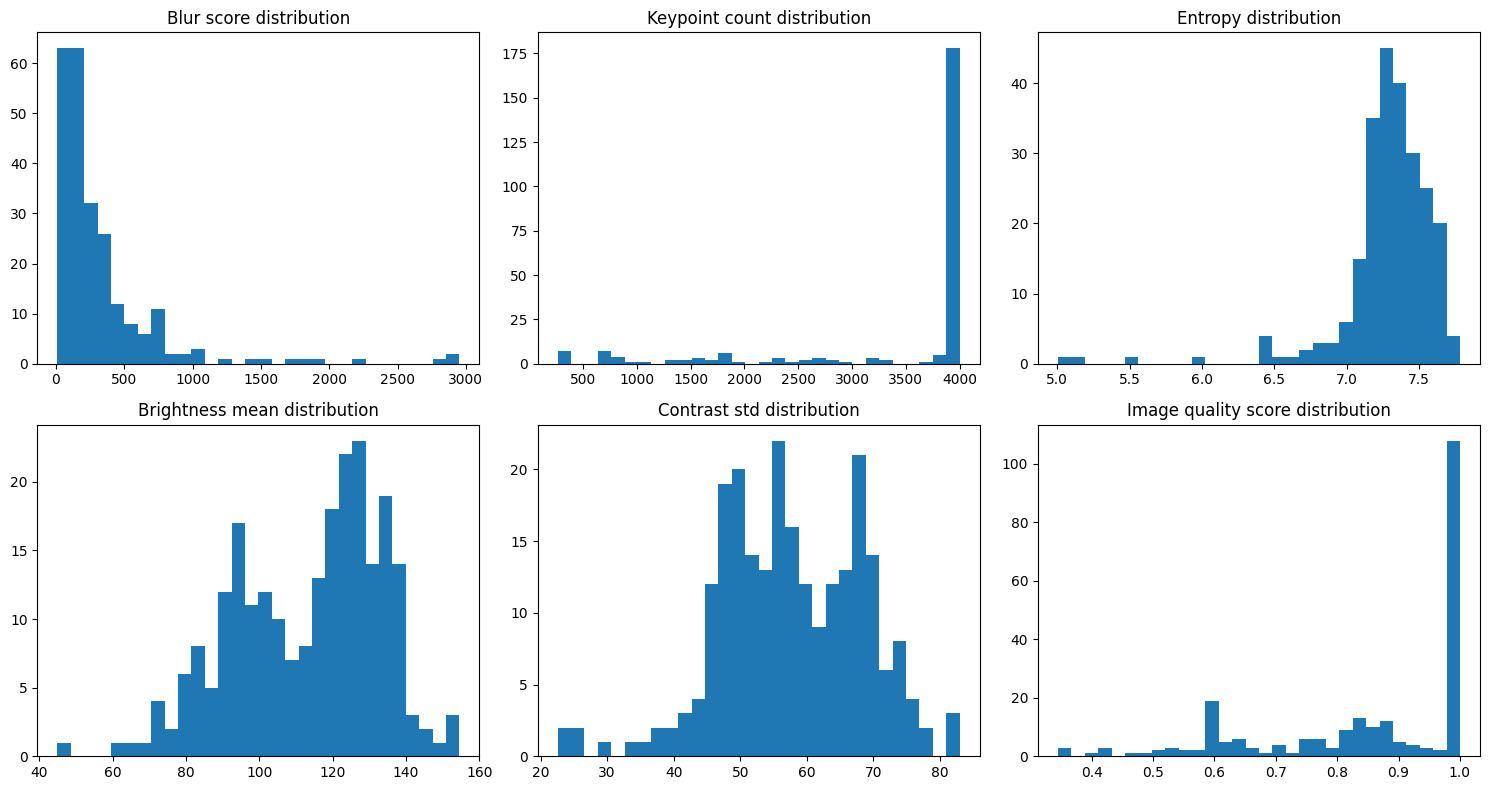

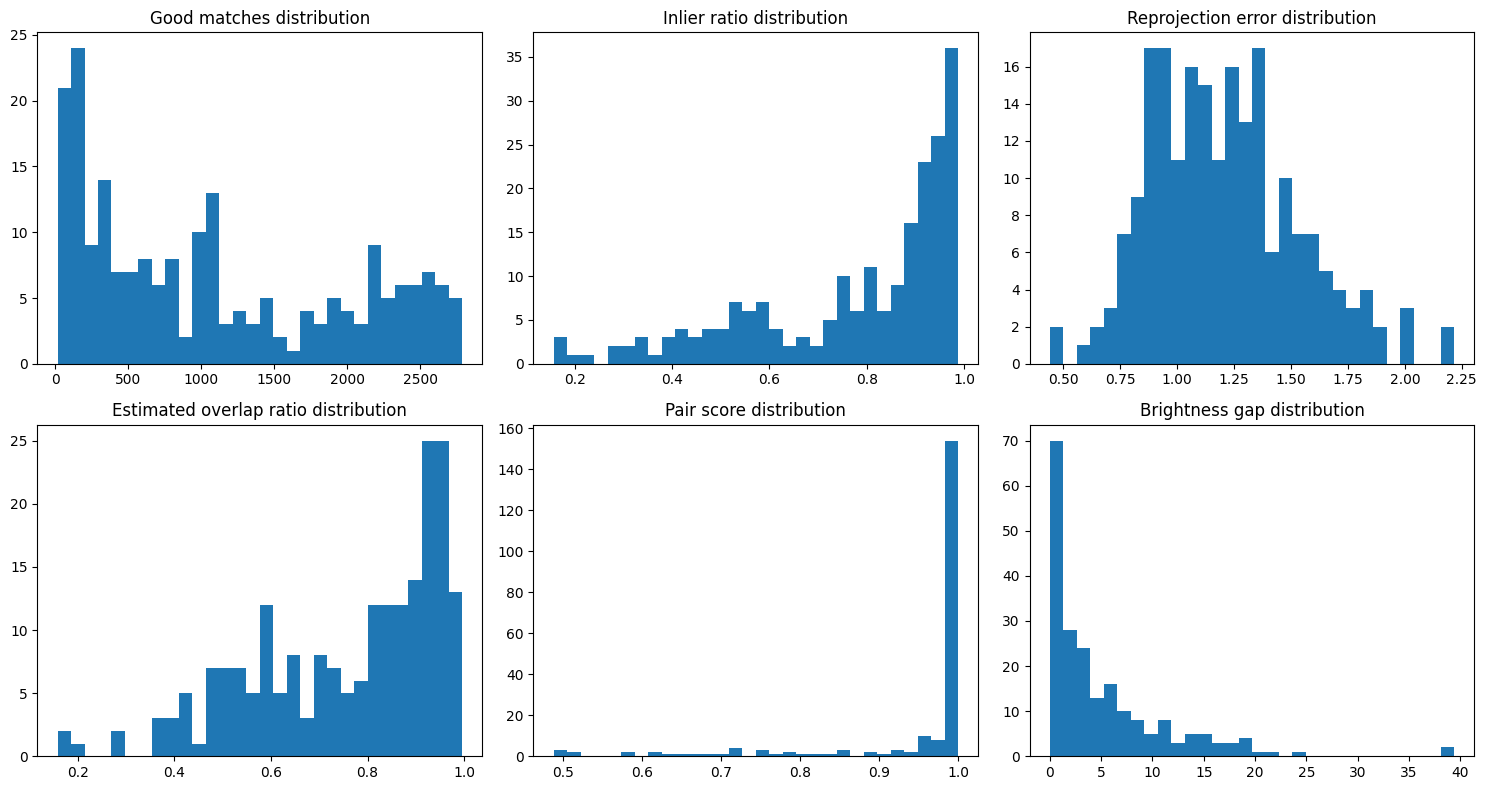

scene_label
likely_good    13
likely_fail     9
borderline      6
Name: scene_count, dtype: int64

audit_vs_opencv
aligned                    19
needs_manual_judgment       6
audit_more_conservative     2
audit_more_optimistic       1
Name: scene_count, dtype: int64

In [23]:
if not df_images.empty:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes[0, 0].hist(df_images['blur_score'], bins=30)
    axes[0, 0].set_title('Blur score distribution')
    axes[0, 1].hist(df_images['keypoints'], bins=30)
    axes[0, 1].set_title('Keypoint count distribution')
    axes[0, 2].hist(df_images['entropy'], bins=30)
    axes[0, 2].set_title('Entropy distribution')
    axes[1, 0].hist(df_images['brightness_mean'], bins=30)
    axes[1, 0].set_title('Brightness mean distribution')
    axes[1, 1].hist(df_images['contrast_std'], bins=30)
    axes[1, 1].set_title('Contrast std distribution')
    axes[1, 2].hist(df_images['image_quality_score'], bins=30)
    axes[1, 2].set_title('Image quality score distribution')
    plt.tight_layout()
    plt.show()

if not df_pairs.empty:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes[0, 0].hist(df_pairs['good_matches'], bins=30)
    axes[0, 0].set_title('Good matches distribution')
    axes[0, 1].hist(df_pairs['inlier_ratio'], bins=30)
    axes[0, 1].set_title('Inlier ratio distribution')
    valid_reproj = df_pairs[np.isfinite(df_pairs['reprojection_error'])]['reprojection_error']
    axes[0, 2].hist(valid_reproj, bins=30)
    axes[0, 2].set_title('Reprojection error distribution')
    axes[1, 0].hist(df_pairs['overlap_ratio'], bins=30)
    axes[1, 0].set_title('Estimated overlap ratio distribution')
    axes[1, 1].hist(df_pairs['pair_score'], bins=30)
    axes[1, 1].set_title('Pair score distribution')
    axes[1, 2].hist(df_pairs['brightness_gap'], bins=30)
    axes[1, 2].set_title('Brightness gap distribution')
    plt.tight_layout()
    plt.show()

if not df_scenes.empty:
    display(df_scenes['scene_label'].value_counts(dropna=False).rename('scene_count'))
    if 'audit_vs_opencv' in df_scenes:
        display(df_scenes['audit_vs_opencv'].value_counts(dropna=False).rename('scene_count'))


## Module 15. Inspect One Scene Manually

Đây là cell để đào sâu một scene cụ thể sau khi auto-audit.

Workflow khuyến nghị:
1. chạy toàn dataset
2. tìm scene `borderline`, `likely_fail`, hoặc `audit_more_optimistic`
3. đặt `SCENE_TO_INSPECT`
4. xem ảnh gốc + pair metrics + skip-pair metrics

Cell này đặc biệt hữu ích khi bạn muốn trả lời câu hỏi kiểu:
- scene này yếu ở pair nào?
- tại sao data audit nhìn tốt nhưng OpenCV lại fail?


In [24]:
SCENE_TO_INSPECT = None  # e.g. 'scene_08'

if SCENE_TO_INSPECT:
    scene_dir = DATA_ROOT / SCENE_TO_INSPECT
    files = list_image_files(scene_dir)
    reference_files = list_reference_files(scene_dir)
    meta_context = scene_context_row(scene_dir)

    display(pd.DataFrame([meta_context]))
    print('Ordered files:', [path.name for path in files])
    if reference_files:
        print('Reference files (excluded from audit chain):', [path.name for path in reference_files])

    for path in files:
        show_bgr(load_bgr(path), title=f'{SCENE_TO_INSPECT} - {path.name}')

    if reference_files:
        for path in reference_files:
            show_bgr(load_bgr(path), title=f'{SCENE_TO_INSPECT} - reference - {path.name}')

    if not df_pairs.empty:
        print("\nAdjacent pair metrics:")
        display(df_pairs[df_pairs['scene_id'] == SCENE_TO_INSPECT].sort_values(['pair_gap', 'pair_score']))

    if not df_skip_pairs.empty:
        print("\nSkip-pair metrics:")
        display(df_skip_pairs[df_skip_pairs['scene_id'] == SCENE_TO_INSPECT].sort_values(['pair_gap', 'pair_score']))
else:
    print('Set SCENE_TO_INSPECT to inspect one scene in detail.')


Set SCENE_TO_INSPECT to inspect one scene in detail.


## Suggested Interpretation

### `likely_good`
- adjacent pairs đều sạch
- không có `skip-pair` gãy rõ
- dùng tốt cho nhóm success/core benchmark

### `borderline`
- có ít nhất một mắt xích yếu
- hoặc pairwise ổn nhưng `skip-pair` cho thấy chuỗi toàn cục chưa thật sạch
- nên xem bằng mắt và đối chiếu với OpenCV

### `likely_fail`
- có pair fail cứng
- hoặc chain có dấu hiệu gãy ở mức toàn cục
- phù hợp cho nhóm failure analysis / hard case review

### `audit_vs_opencv`
- `aligned`: audit và OpenCV kể cùng một câu chuyện
- `audit_more_optimistic`: pairwise audit đang lạc quan hơn stitch thật
- `audit_more_conservative`: audit đang nghiêm hơn stitch thật
- `needs_manual_judgment`: scene ở vùng xám, nên kiểm trực tiếp
